### class torch.nn.GRU(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False, device=None, dtype=None)

***

In [2]:
import torch
import torch.nn as nn
import numpy as np

import urllib.request

# 1. Download the Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

# 2. Read the text file into a string
with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Length of dataset in characters: {len(text)}")

# 3. For a quick 2-hour learning session, let's slice the first 10,000 characters. 
# (Training on the full 1 million characters takes much longer!)
#text = text[:10000]

# 4. Build the vocabulary exactly as we did before
words = text.lower().split()
vocab = sorted(set(words))
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for word, i in word_to_ix.items()}

print(f"Vocabulary size: {vocab_size} unique words")



Length of dataset in characters: 1115394
Vocabulary size: 23641 unique words


In [3]:
def text_to_onehot(string):
    tensor = torch.zeros(len(string), vocab_size)
    for i, word in enumerate(string):
        tensor[i, word_to_ix[word]] = 1.0
    return tensor

def words_to_indices(string):
    return torch.tensor([word_to_ix[word] for word in string], dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import torch
import torch.nn as nn

class wordGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=64, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        self.gru = nn.GRU(
            input_size=embed_dim, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: [batch_size, seq_len]
        x = self.embedding(x)   # [batch_size, seq_len, embed_dim]
        
        batch_size = x.size(0)

        # Initialize hidden state if not provided
        if hidden is None:
            # NOTICE: Only h0 is needed! No c0 like in the LSTM.
            hidden = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)

        # Pass through GRU
        out, hn = self.gru(x, hidden)   # out: [batch_size, seq_len, hidden_size]
        
        # Apply FC layer to ALL time steps (Many-to-Many)
        prediction = self.fc(out)       # [batch_size, seq_len, vocab_size]

        return prediction, hn

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# ----------------------------
# Hyperparameters
# ----------------------------
hl = 64
num_epoch = 20
batch_size = 64
seq_len = 20
lr = 0.01
embed_dim = 64

samples = []

for i in range(len(words) - seq_len):
    input_seq = words[i:i+seq_len]
    target_seq = words[i+1:i+seq_len+1]

    input_tensor = words_to_indices(input_seq)    # [seq_len]
    target_tensor = words_to_indices(target_seq)  # [seq_len]

    samples.append((input_tensor, target_tensor))

train_size = int(0.8 * len(samples))
val_size = len(samples) - train_size

train_dataset, val_dataset = random_split(samples, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

import copy
import matplotlib.pyplot as plt

# ----------------------------
# GATE TRACKING SETUP
# ----------------------------
# PyTorch always chunks LSTM weights in this exact order:
gate_names = ['Input (i)', 'Forget (f)', 'Cell (g)', 'Output (o)']
gate_weight_changes = {gate: [] for gate in gate_names}

def get_gru_weights(model):
    # Concatenate the input-hidden and hidden-hidden weights into one matrix
    # .detach().clone() ensures we get a snapshot that isn't attached to the computational graph
    return torch.cat([
        model.gru.weight_ih_l0.detach().clone(),
        model.gru.weight_hh_l0.detach().clone()
    ], dim=1)




In [6]:
embed_dim = 64
hidden_size = 64

model = wordGRU(vocab_size=vocab_size, embed_dim=embed_dim, hidden_size=hidden_size, num_layers=1).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Store the initial weights before training starts
prev_weights = get_gru_weights(model)

for epoch in range(num_epoch):
    # ----------------------------
    # Training
    # ----------------------------
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for seq_batch, target_batch in trainloader:
        seq_batch = seq_batch.to(device)         # [batch_size, seq_len]
        target_batch = target_batch.to(device)   # [batch_size, seq_len]

        optimizer.zero_grad()

        predictions, hidden = model(seq_batch)   # [batch_size, seq_len, vocab_size]

        prediction_flat = predictions.reshape(-1, vocab_size)   # [batch_size * seq_len, vocab_size]
        labels_flat = target_batch.reshape(-1)                  # [batch_size * seq_len]

        loss = criterion(prediction_flat, labels_flat)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        preds = torch.argmax(prediction_flat, dim=1)
        train_correct += (preds == labels_flat).sum().item()
        train_total += labels_flat.size(0)

    epoch_train_loss = running_train_loss / len(trainloader)
    epoch_train_acc = train_correct / train_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for seq_batch, target_batch in valloader:
            seq_batch = seq_batch.to(device)
            target_batch = target_batch.to(device)

            predictions, hidden = model(seq_batch)

            prediction_flat = predictions.reshape(-1, vocab_size)
            labels_flat = target_batch.reshape(-1)

            loss = criterion(prediction_flat, labels_flat)
            running_val_loss += loss.item()

            preds = torch.argmax(prediction_flat, dim=1)
            val_correct += (preds == labels_flat).sum().item()
            val_total += labels_flat.size(0)

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epoch}] "
        f"| Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} "
        f"| Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

    # ----------------------------
    # MEASURE WEIGHT CHANGES
    # ----------------------------
    curr_weights = get_gru_weights(model)
    
    # Calculate the absolute difference from the previous epoch
    weight_diff = curr_weights - prev_weights
    
    # Split the giant tensor back into the 4 individual gates
    gate_diffs = weight_diff.chunk(4, dim=0)
    
    for i, gate in enumerate(gate_names):
        # Calculate the L2 norm (magnitude) of the weight change for this specific gate
        change_magnitude = gate_diffs[i].norm().item()
        gate_weight_changes[gate].append(change_magnitude)
        
    # Set the current weights as the 'previous' weights for the next loop
    prev_weights = curr_weights

Epoch [1/20] | Train Loss: 4.6064 | Train Acc: 0.2199 | Val Loss: 3.4179 | Val Acc: 0.3390
Epoch [2/20] | Train Loss: 3.0465 | Train Acc: 0.3970 | Val Loss: 2.8598 | Val Acc: 0.4263
Epoch [3/20] | Train Loss: 2.6417 | Train Acc: 0.4625 | Val Loss: 2.5839 | Val Acc: 0.4723
Epoch [4/20] | Train Loss: 2.4163 | Train Acc: 0.5019 | Val Loss: 2.4070 | Val Acc: 0.5051
Epoch [5/20] | Train Loss: 2.2656 | Train Acc: 0.5285 | Val Loss: 2.2853 | Val Acc: 0.5261
Epoch [6/20] | Train Loss: 2.1555 | Train Acc: 0.5486 | Val Loss: 2.1919 | Val Acc: 0.5449
Epoch [7/20] | Train Loss: 2.0716 | Train Acc: 0.5647 | Val Loss: 2.1116 | Val Acc: 0.5590
Epoch [8/20] | Train Loss: 2.0060 | Train Acc: 0.5769 | Val Loss: 2.0601 | Val Acc: 0.5703
Epoch [9/20] | Train Loss: 1.9513 | Train Acc: 0.5875 | Val Loss: 2.0120 | Val Acc: 0.5773
Epoch [10/20] | Train Loss: 1.9070 | Train Acc: 0.5959 | Val Loss: 1.9711 | Val Acc: 0.5861
Epoch [11/20] | Train Loss: 1.8686 | Train Acc: 0.6034 | Val Loss: 1.9363 | Val Acc: 0.59

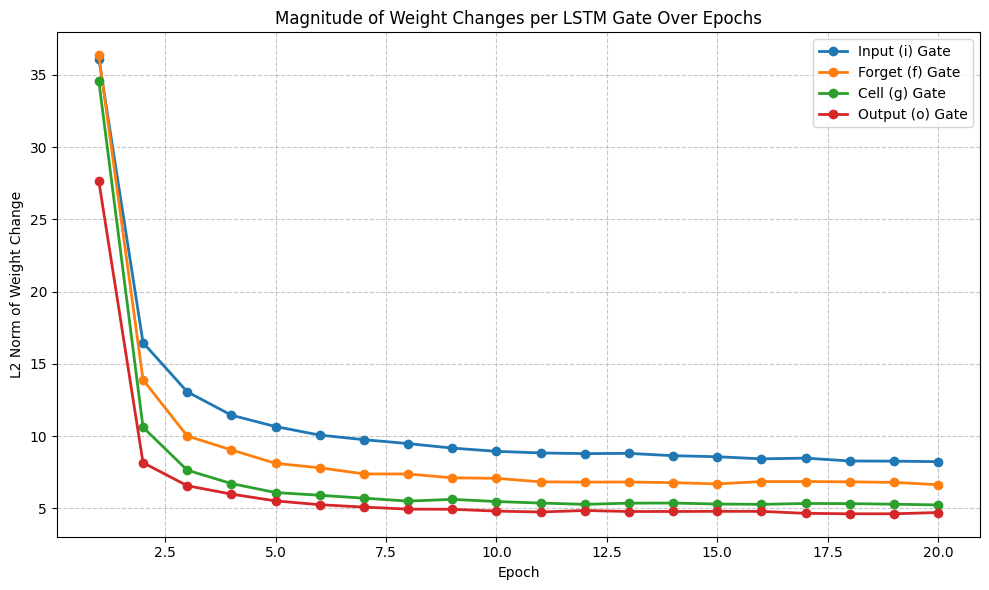

In [7]:


# ----------------------------
# VISUALIZE GATE DYNAMICS
# ----------------------------
plt.figure(figsize=(10, 6))
epochs_range = range(1, num_epoch + 1)

for gate in gate_names:
    plt.plot(epochs_range, gate_weight_changes[gate], label=f'{gate} Gate', marker='o', linewidth=2)

plt.title('Magnitude of Weight Changes per LSTM Gate Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('L2 Norm of Weight Change')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
def generate_text(model, start_word, predict_len=10):
    model.eval()

    if start_word not in word_to_ix:
        return f"Word '{start_word}' not in vocabulary."

    current_word = start_word
    generated_words = [start_word]
    hidden = None

    with torch.no_grad():
        for _ in range(predict_len):
            current_idx = torch.tensor([[word_to_ix[current_word]]], dtype=torch.long).to(device)
            output, hidden = model(current_idx, hidden)

            predicted_index = torch.argmax(output[0, -1], dim=-1).item()
            current_word = ix_to_word[predicted_index]
            generated_words.append(current_word)

    return " ".join(generated_words)

print(generate_text(model, start_word="hell", predict_len=10))

hell and poesy use to quicken you; the mathematics and the
